In [208]:
# from logit_model import *
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from statsmodels.stats.outliers_influence import variance_inflation_factor




In [210]:
import seaborn as sns
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)


In [211]:
from package_files.benefits_defns import *

In [159]:
benefits3

['CAREER_DEV',
 'EDU_ASSISTANCE',
 'WLB',
 'WELLBEING',
 'HEALTH_WELLBEING',
 'RECOGNITION',
 'FAMILY',
 'PARENTAL_LEAVE',
 'CULTURE']

In [78]:
pd.set_option('display.max_columns', None)

In [212]:
path = '../../data/salary_sample_2018_2023.parquet.gzip'

In [213]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [81]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,False,True,False,True,False,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,False,True,False,False,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P..

In [82]:
region = 'STATE_NAME'
industry = 'NAICS_2022_2_NAME'
education = 'MIN_EDULEVELS_NAME'
year = 'YEAR'
occupation = 'SOC_2021_2_NAME'
experience = 'EXPERIENCE_BUCKET'

# Define Function

In [83]:
def run_logit_model(data, dependent, cat_controls=[], cont_controls = [], binary_vars = [], predictor = 'Has AI Skills', ref_category = None, get_vif = False):
    """
    Runs a logistic regression model to predict work-from-home dependent status based on the specified predictor
    and control variables.

    Parameters:
    -----------
    controls : list of str
        A list of column names to be used as control variables. These variables will be converted to categorical
        variables and dummy variables will be created for them.
    predictor : str, default='Has AI Skills'
        The column name of the primary predictor variable.
    data : pd.DataFrame, default=data
        The DataFrame containing the data.
    ref_category : dict, optional
        A dictionary specifying the reference category for each control variable where keys are column names
        and values are the reference categories.

    Returns:
    --------
    logit_model : statsmodels.discrete.discrete_model.BinaryResultsWrapper
        The fitted logistic regression model.

    Example:
    --------
    >>> controls = ['region_column_name', 'industry_column_name']
    >>> model = run_wfh_logit(controls, predictor='Has AI Skills', data=data)
    >>> print(model.summary())
    """
    X = data[[predictor]]
    
    if binary_vars:
        for var in binary_vars:
            X = pd.concat([X, data[[var]]], axis = 1)
    
    if cont_controls:
        for cc in cont_controls:
            X = pd.concat([X, data[[cc]]], axis = 1)
    
    if cat_controls:
        for c in cat_controls:    
            # Create categorical variables 
            data[c] = data[c].astype('category')
            
            # Create dummy variables with specified reference category
            if ref_category and c in ref_category:
                # Ensure the reference category is present in the data
                if ref_category[c] in data[c].cat.categories:
                    data[c] = data[c].cat.reorder_categories(
                        [ref_category[c]] + [cat for cat in data[c].cat.categories if cat != ref_category[c]],
                        ordered=True
                    )
                    dummies = pd.get_dummies(data[c], drop_first=True)
            # Create dummy variables
                else:
                    raise ValueError(f"Reference category '{ref_category[c]}' not found in column '{c}'")
            else:
                dummies = pd.get_dummies(data[c], drop_first=True)
            X = pd.concat([X, dummies], axis = 1)

    X = X.apply(pd.to_numeric, errors='coerce')

    y = data[dependent]
    data = pd.concat([X, y], axis=1).dropna()
    X = data.drop(columns = dependent)
    y = data[dependent]
    X = sm.add_constant(X)
    y = pd.to_numeric(y, errors='coerce')

    X.columns = X.columns.astype(str)

    X = X.astype(float)
    y = y.astype(float)
    # print(X)
    # print(X.corr())
    
    if get_vif:
        print("VIF Results")
        vif_data = []
        for i in tqdm(range(X.shape[1]), desc="Calculating VIF"):
            vif = variance_inflation_factor(X.values, i)
            vif_data.append(vif)
        vif = pd.DataFrame()
        vif["features"] = X.columns
        vif["VIF"] = vif_data
        print(vif)
        print("Correlation Matrix")
        # create new df combine X and y for correlation matrix
        dummy_df = pd.concat([X, y], axis=1)
        dummy_corr_matrix = dummy_df.corr()
        # print any correlations above 0.7
        print(dummy_corr_matrix[dummy_corr_matrix > 0.6])
        
    # if error, continue to next model
    try:
        logit_model = sm.Logit(y, X).fit()
    except Exception as error:
        # print error
        print(error)
        return "Error"

    # Print the summary of the model
    print(logit_model.summary())
    # print(summary_col(logit_model, stars=True, float_format='%0.2f'))
    return logit_model

In [112]:
def get_dummy_df(data, dependent, cat_controls=[], cont_controls = [], binary_vars = [], predictor = 'Has AI Skills', ref_category = None):
    X = data[[predictor]]
    
    if binary_vars:
        for var in binary_vars:
            X = pd.concat([X, data[[var]]], axis = 1)
    
    if cont_controls:
        for cc in cont_controls:
            X = pd.concat([X, data[[cc]]], axis = 1)
    
    if cat_controls:
        for c in cat_controls:    
            # Create categorical variables 
            data[c] = data[c].astype('category')
            
            # Create dummy variables with specified reference category
            if ref_category and c in ref_category:
                # Ensure the reference category is present in the data
                if ref_category[c] in data[c].cat.categories:
                    data[c] = data[c].cat.reorder_categories(
                        [ref_category[c]] + [cat for cat in data[c].cat.categories if cat != ref_category[c]],
                        ordered=True
                    )
                    dummies = pd.get_dummies(data[c], drop_first=True)
            # Create dummy variables
                else:
                    raise ValueError(f"Reference category '{ref_category[c]}' not found in column '{c}'")
            else:
                dummies = pd.get_dummies(data[c], drop_first=True)
            X = pd.concat([X, dummies], axis = 1)

    X = X.apply(pd.to_numeric, errors='coerce')

    y = data[dependent]
    data = pd.concat([X, y], axis=1).dropna()
    X = data.drop(columns = dependent)
    y = data[dependent]
    X = sm.add_constant(X)
    y = pd.to_numeric(y, errors='coerce')

    X.columns = X.columns.astype(str)

    X = X.astype(float)
    y = y.astype(float)
    dummy_df = pd.concat([X, y], axis=1)
    return dummy_df
    

# Models with Only Year and Occupation Control

In [180]:
benefits = ['CAREER_DEV', 'EDU_ASSISTANCE','WLB', 'WELLBEING', 'HEALTH_WELLBEING','RECOGNITION', 'FAMILY', 'PARENTAL_LEAVE','CULTURE']


In [85]:
benefit_models = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation], get_vif = True)
    benefit_models.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 23.93it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 20.18it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

...

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


         Current function value: 0.246186
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 25.87it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [86]:
# benefit_models = []
# for benefit in benefits:
#     print(benefit)
#     print('--'*100)
#     model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation])
#     benefit_models.append(model)

In [87]:
# # export benefit_models to pickle
# import pickle
# if path[-3:] == 'csv:':
#     with open('../exports/benefit_models.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)
# elif path == '../data/salary_sample_body_benefits.parquet.gzip'
#     with open('../exports/benefit_models_fromlarge.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)

# With Individual Controls

In [88]:
benefit_models_2 = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation, education],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = True)
    benefit_models_2.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 32.45it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 24.91it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

...

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 33.32it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [89]:
benefit_models_2

 'Error',
 'Error',
 'Error',

In [90]:
pd.set_option('display.max_rows', 100)

In [91]:
even_sample.groupby([occupation, education]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/3366778209.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby([occupation, education]).size()


SOC_2021_2_NAME                           MIN_EDULEVELS_NAME          
Architecture and Engineering Occupations  No Education Listed              67
                                          Associate degree                 29
                                          Bachelor's degree               271
                                          High school or GED               39
                                          Master's degree                  13
                                                                         ... 
Unclassified Occupation                   Associate degree                 34
                                          Bachelor's degree               286
                                          High school or GED               95
                                          Master's degree                  70
                                          Ph.D. or professional degree     52
Length: 144, dtype: int64

In [92]:
even_sample.groupby([occupation, experience]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/2438234741.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby([occupation, experience]).size()


SOC_2021_2_NAME                           EXPERIENCE_BUCKET
Architecture and Engineering Occupations  0 years                6
                                          1-2 years             62
                                          11-20 years           19
                                          3-5 years            135
                                          6-10 years            85
                                                              ... 
Unclassified Occupation                   1-2 years            109
                                          11-20 years           29
                                          3-5 years            178
                                          6-10 years           117
                                          None Listed          249
Length: 144, dtype: int64

In [93]:
even_sample.groupby(['AI ROLE', education]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/2998860356.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby(['AI ROLE', education]).size()


AI ROLE  MIN_EDULEVELS_NAME          
False    No Education Listed             5046
         Associate degree                 475
         Bachelor's degree               1516
         High school or GED              2743
         Master's degree                  143
         Ph.D. or professional degree      77
True     No Education Listed             2537
         Associate degree                 307
         Bachelor's degree               5668
         High school or GED               626
         Master's degree                  618
         Ph.D. or professional degree     244
dtype: int64

In [94]:
even_sample.groupby(['AI ROLE', experience]).size()

AI ROLE  EXPERIENCE_BUCKET
False    0 years               513
         1-2 years            2165
         11-20 years            45
         3-5 years            1363
         6-10 years            343
         None Listed          5571
True     0 years               150
         1-2 years            1048
         11-20 years           360
         3-5 years            3336
         6-10 years           2359
         None Listed          2747
dtype: int64

In [95]:
# import pickle
# if path[-3:] == 'csv:':
#     with open('../exports/benefit_models_2.pkl', 'wb') as f:
#         pickle.dump(benefit_models_2, f)
# elif path == '../data/salary_sample_body_benefits.parquet.gzip'
#     with open('../exports/benefit_models_fromlarge_2.pkl', 'wb') as f:
#         pickle.dump(benefit_models_2, f)

# With Salary Control

In [96]:
benefit_models_3 = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_3.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.501541
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             CAREER_DEV   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.02728
Time:                        12:02:44   Log-Likelihood:                -10031.
converged:                       True   LL-Null:                       -10312.
Covariance Type:            nonrobust   LLR p-value:                 5.118e-94
                                                      

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.238833
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:       HEALTH_WELLBEING   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.04716
Time:                        12:02:47   Log-Likelihood:                -4776.7
converged:                      False   LL-Null:                       -5013.1
Covariance Type:            nonrobust   LLR p-value:                 6.752e-76
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.078110
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            RECOGNITION   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.06880
Time:                        12:02:48   Log-Likelihood:                -1562.2
converged:                      False   LL-Null:                       -1677.6
Covariance Type:            nonrobust   LLR p-value:                 4.537e-29
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.268593
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 FAMILY   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                 0.08351
Time:                        12:02:49   Log-Likelihood:                -5371.9
converged:                      False   LL-Null:                       -5861.3
Covariance Type:            nonrobust   LLR p-value:                5.835e-180
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
         Current function value: 0.291850
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                CULTURE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                  0.1085
Time:                        12:02:50   Log-Likelihood:                -5837.0
converged:                      False   LL-Null:                       -6547.7
Covariance Type:            nonrobust   LLR p-value:                4.791e-273
                

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [97]:
benefit_models_3

 'Error',

# Troubleshooting

## Check for Multicollinearity

In [115]:
dummy_df = get_dummy_df(even_sample, dependent = 'PARENTAL_LEAVE', predictor='AI ROLE', cat_controls = [year, occupation, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})

In [116]:
dummy_df

,const,AI ROLE,LOG_SALARY,2020,2021,2022,2023,"Arts, Design, Entertainment, Sports, and Media Occupations",Building and Grounds Cleaning and Maintenance Occupations,Business and Financial Operations Occupations,Community and Social Service Occupations,Computer and Mathematical Occupations,Construction and Extraction Occupations,Educational Instruction and Library Occupations,"Farming, Fishing, and Forestry Occupations",Food Preparation and Serving Related Occupations,Healthcare Practitioners and Technical Occupations,Healthcare Support Occupations,"Installation, Maintenance, and Repair Occupations",Legal Occupations,"Life, Physical, and Social Science Occupations",Management Occupations,Military-only occupations,Office and Administrative Support Occupations,Personal Care and Service Occupations,Production Occupations,Protective Service Occupations,Sales and Related Occupations,Transportation and Material Moving Occupations,Unclassified Occupation,Associate degree,Bachelor's degree,High school or GED,Master's degree,Ph.D. or professional degree,0 years,1-2 years,11-20 years,3-5 years,6-10 years,PARENTAL_LEAVE
0,1.0,1.0,12.177416,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,1.0,11.813585,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,11.169900,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,11.670356,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,1.0,11.407565,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1.0,0.0,10.635855,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19996,1.0,0.0,10.551899,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19997,1.0,0.0,10.097573,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19998,1.0,0.0,10.544288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [125]:
# get correlations > 0.5
dummy_corr_matrix = dummy_df.corr()
dummy_corr_matrix[(dummy_corr_matrix > 0.4) | (dummy_corr_matrix < -0.4)].stack().reset_index()



,level_0,level_1,0
0,AI ROLE,AI ROLE,1.000000
1,AI ROLE,LOG_SALARY,0.619571
2,AI ROLE,Computer and Mathematical Occupations,0.530920
3,AI ROLE,Bachelor's degree,0.432711
4,LOG_SALARY,AI ROLE,0.619571
5,LOG_SALARY,LOG_SALARY,1.000000
6,LOG_SALARY,Computer and Mathematical Occupations,0.510784
7,LOG_SALARY,Bachelor's degree,0.433489
8,LOG_SALARY,High school or GED,-0.400604
9,2020,2020,1.000000


In [124]:
# Filter correlations greater than 0.5 or less than -0.5, excluding diagonal (correlation of a variable with itself)
high_corr = dummy_corr_matrix[(dummy_corr_matrix > 0.5) | (dummy_corr_matrix < -0.5)].stack().reset_index()

# Renaming columns for better readability
high_corr.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove self-correlations (where Variable 1 and Variable 2 are the same)
high_corr = high_corr[high_corr['Variable 1'] != high_corr['Variable 2']]

# Print the high correlations
high_corr

,Variable 1,Variable 2,Correlation
1,AI ROLE,LOG_SALARY,0.619571
2,AI ROLE,Computer and Mathematical Occupations,0.530920
3,LOG_SALARY,AI ROLE,0.619571
5,LOG_SALARY,Computer and Mathematical Occupations,0.510784
14,Computer and Mathematical Occupations,AI ROLE,0.530920
15,Computer and Mathematical Occupations,LOG_SALARY,0.510784


## Variation

In [141]:
even_sample[benefits]

,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE
0,False,False,False,False,False,False,False,False,True
1,False,False,True,False,True,False,False,False,False
2,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
19995,False,False,True,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False
19997,True,True,True,True,True,False,True,True,False
19998,True,False,False,False,False,False,False,False,False


In [143]:
for benefit in benefits:
    print(even_sample[benefit].sum())

4225
1837
7420
925
1377
329
1719
1537
2021


In [152]:
benefits3_labels

['Career Development',
 'Education Assistance',
 'Work-Life Balance',
 'Wellbeing',
 'Recognition',
 'Family',
 'Parental Leave',
 'Culture']

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Career Development'),
  Text(1, 0, 'Education Assistance'),
  Text(2, 0, 'Work-Life Balance'),
  Text(3, 0, 'Wellbeing'),
  Text(4, 0, 'Health and Wellbeing'),
  Text(5, 0, 'Recognition'),
  Text(6, 0, 'Family'),
  Text(7, 0, 'Parental Leave'),
  Text(8, 0, 'Culture')])

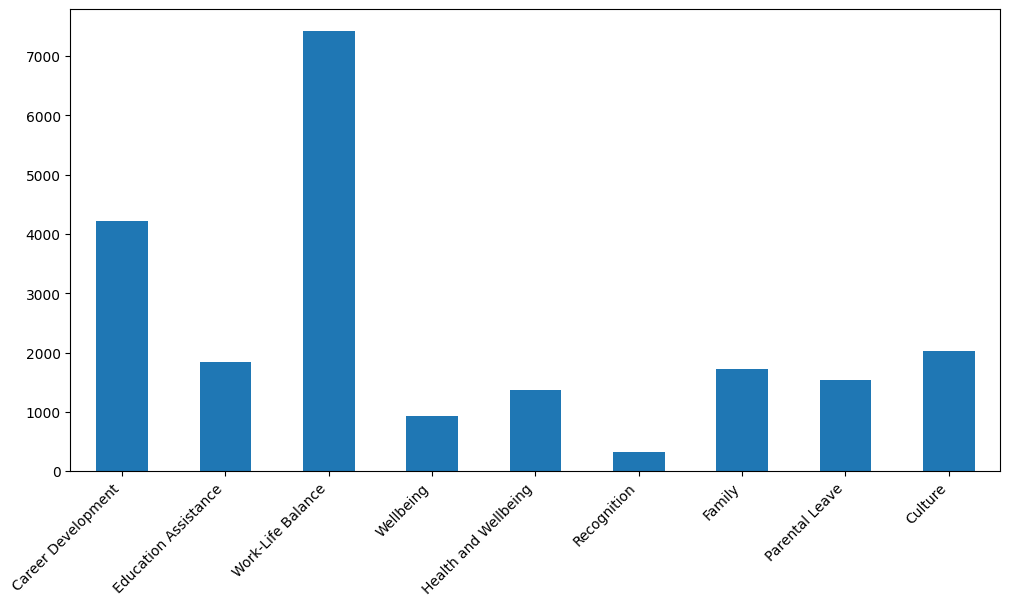

In [161]:

    
# plot a clustered bar chart for all benefits
benefit_counts = even_sample[benefits3].sum()
benefit_counts.plot(kind='bar', figsize=(12, 6))
# rotate x labels
# set labels as benefits3_labels
plt.xticks(ticks=range(len(benefits3_labels)),labels=benefits3_labels)
plt.xticks(rotation=45, ha='right')



In [126]:
even_sample['PARENTAL_LEAVE'].value_counts()

PARENTAL_LEAVE
False    18463
True      1537
Name: count, dtype: int64

# Plot Coefficients

In [98]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df = pd.DataFrame(results)



In [99]:
results_df

,Label,Coefficient,Error,P-Value
0,CAREER_DEV,0.014385,0.046544,0.757
1,EDU_ASSISTANCE,0.017867,0.065632,0.785
2,WLB,-0.174237,0.040048,0.000
3,WELLBEING,0.533514,0.094908,0.000
4,HEALTH_WELLBEING,0.396024,0.077583,0.000
5,RECOGNITION,0.094436,0.154843,0.542
6,FAMILY,0.447628,0.070732,0.000
7,PARENTAL_LEAVE,NaN,NaN,NaN
8,CULTURE,0.662077,0.068184,0.000


In [100]:
results_df['Model Iteration'] = 'Baseline'

In [101]:
results_df

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.014385,0.046544,0.757,Baseline
1,EDU_ASSISTANCE,0.017867,0.065632,0.785,Baseline
2,WLB,-0.174237,0.040048,0.000,Baseline
3,WELLBEING,0.533514,0.094908,0.000,Baseline
4,HEALTH_WELLBEING,0.396024,0.077583,0.000,Baseline
5,RECOGNITION,0.094436,0.154843,0.542,Baseline
6,FAMILY,0.447628,0.070732,0.000,Baseline
7,PARENTAL_LEAVE,NaN,NaN,NaN,Baseline
8,CULTURE,0.662077,0.068184,0.000,Baseline


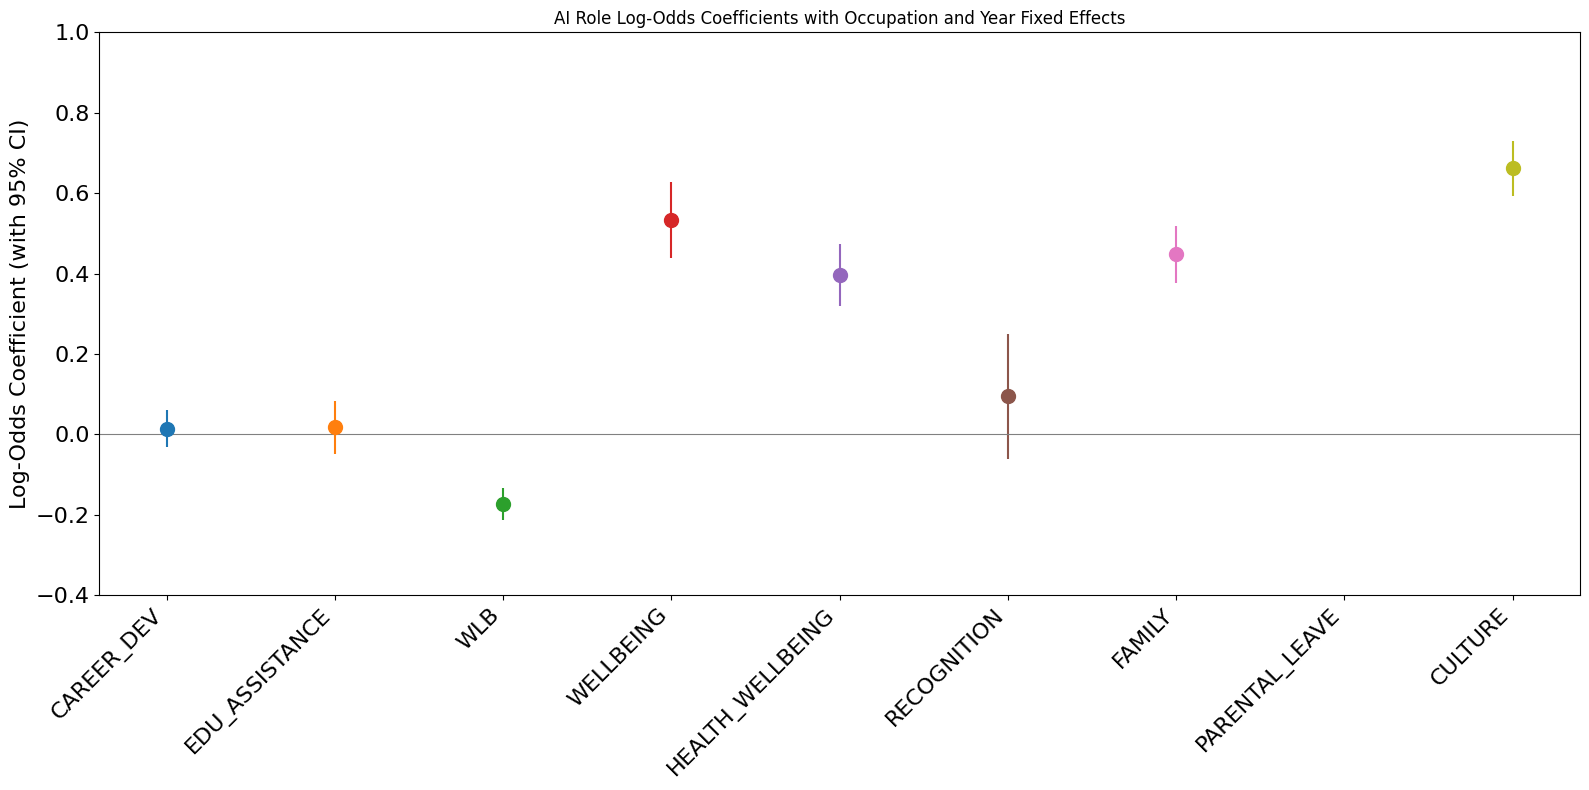

In [102]:
fig, ax = plt.subplots(figsize=(16, 8))
# Define colors for the 9 AI skills categories
# colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#999999']
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(results_df))]
# Plot each AI skill category
for i, row in results_df.iterrows():
    ax.errorbar(
        i, row['Coefficient'], 
        yerr=row['Error'], 
        fmt='o', color=colors[i], label=row['Label'], markersize = 10
    )

# Customize plot
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Label'], rotation=45, ha='right', fontsize = 16)
# ax.set_title('Coefficients for 9 AI Skills Categories')
# ax.set_xlabel('AI Skills Categories', fontsize = 18)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize = 16)
ax.axhline(0, color='grey', linewidth=0.8)
# ax.axhline(average_coefficient, color='grey', linestyle='--', linewidth=1, label='Average Coefficient')

# Increase the size of y-ticks
ax.tick_params(axis='y', labelsize=16)
ax.set_title('AI Role Log-Odds Coefficients with Occupation and Year Fixed Effects')
ax.set_ylim(-0.4, 1.0)
# Add legend
# ax.legend(title='AI Skills', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 16, title_fontsize = 16)

plt.tight_layout() 
plt.show()

In [103]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results_2 = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df_2 = pd.DataFrame(results_2)



In [104]:
results_df_2

,Label,Coefficient,Error,P-Value
0,CAREER_DEV,-0.036362,0.048276,0.451
1,EDU_ASSISTANCE,-0.008501,0.068242,0.901
2,WLB,-0.175347,0.041446,0.000
3,WELLBEING,NaN,NaN,NaN
4,HEALTH_WELLBEING,0.289475,0.080226,0.000
5,RECOGNITION,NaN,NaN,NaN
6,FAMILY,0.466633,0.073098,0.000
7,PARENTAL_LEAVE,NaN,NaN,NaN
8,CULTURE,0.593803,0.070137,0.000


In [105]:
results_df_2['Model Iteration'] = 'Individual Controls'

In [106]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results_3 = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df_3 = pd.DataFrame(results_3)



In [107]:
results_df_3['Model Iteration'] = 'With Salary'

In [108]:
df = pd.concat([results_df, results_df_2, results_df_3])

In [109]:
df

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.014385,0.046544,0.757,Baseline
1,EDU_ASSISTANCE,0.017867,0.065632,0.785,Baseline
2,WLB,-0.174237,0.040048,0.000,Baseline
3,WELLBEING,0.533514,0.094908,0.000,Baseline
4,HEALTH_WELLBEING,0.396024,0.077583,0.000,Baseline
5,RECOGNITION,0.094436,0.154843,0.542,Baseline
6,FAMILY,0.447628,0.070732,0.000,Baseline
7,PARENTAL_LEAVE,NaN,NaN,NaN,Baseline
8,CULTURE,0.662077,0.068184,0.000,Baseline
0,CAREER_DEV,-0.036362,0.048276,0.451,Individual Controls


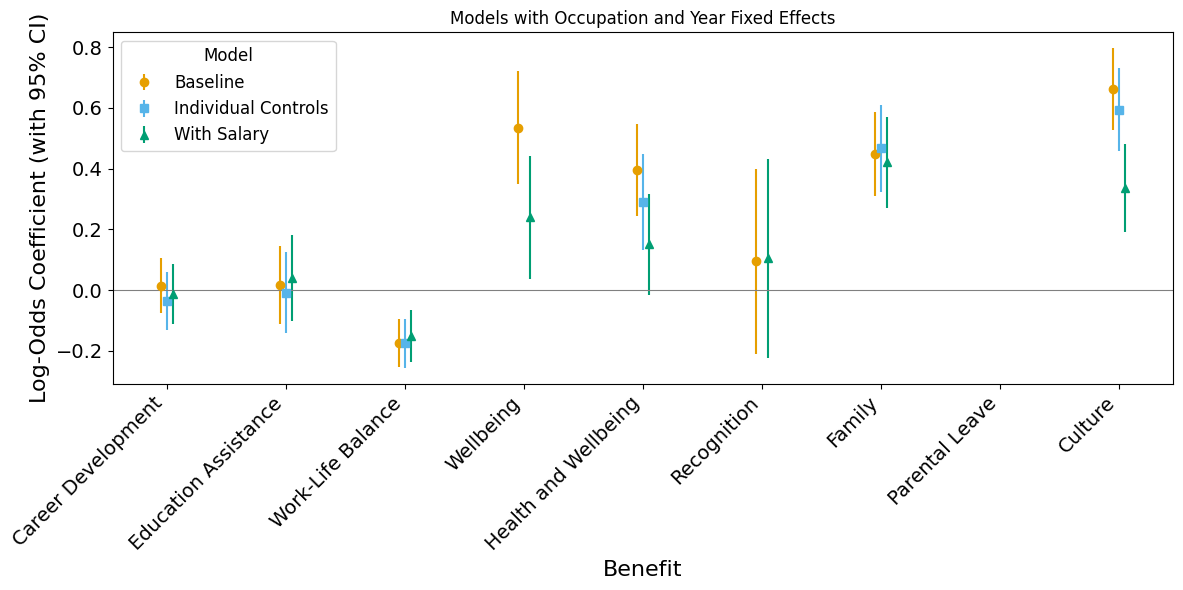

In [206]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
df['Lower_CI'] = df['Coefficient'] - 1.96 * df['Error']
df['Upper_CI'] = df['Coefficient'] + 1.96 * df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits:
    benefit_data = df[df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits))]
ax.set_xticks(benefit_ticks)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits3_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel('Benefit', fontsize=16)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
plt.title('Models with Occupation and Year Fixed Effects')
plt.tight_layout()
plt.savefig('../figures/model_coefficients_plot_3.png')
plt.show()


# Models with Industry

In [214]:
benefits4

['EDU_ASSISTANCE',
 'WLB',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'wfh_wham']

In [227]:
benefit_models_industry = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry])
    benefit_models_industry.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.277745
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19973
Method:                           MLE   Df Model:                           26
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                 0.05419
Time:                        15:25:40   Log-Likelihood:                -5554.9
converged:                       True   LL-Null:                       -5873.1
Covariance Type:            nonrobust   LLR p-value:                1.445e-117
                                                  

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Singular matrix
CULTURE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.344483
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                CULTURE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19973
Method:                           MLE   Df Model:                           26
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                  0.1533
Time:                        15:25:44   Log-Likelihood:                -6889.7
converged:                       True   LL-Null:                       -8137.3
Covariance Type:            nonrobust   LLR p-value:       

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [230]:
benefit_models_industry[0].converged

True

In [225]:
even_sample[even_sample['PARENTAL_LEAVE']==1].groupby([year]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_95399/3776603636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample[even_sample['PARENTAL_LEAVE']==1].groupby([year]).size()


YEAR
2018      4
2019     12
2020     42
2021    163
2022    300
2023    915
dtype: int64

In [226]:
run_logit_model(even_sample, dependent = 'PARENTAL_LEAVE', predictor='AI ROLE', cat_controls = [industry], get_vif = True)


VIF Results


Calculating VIF: 100%|██████████| 22/22 [00:00<00:00, 31.33it/s]


                                             features        VIF
0                                               const  35.538857
1                                             AI ROLE   1.168564
2   Administrative and Support and Waste Managemen...   5.870419
3          Agriculture, Forestry, Fishing and Hunting   1.043068
4                 Arts, Entertainment, and Recreation   1.186498
5                                        Construction   1.499693
6                                Educational Services   2.449045
7                               Finance and Insurance   3.347189
8                   Health Care and Social Assistance   2.807832
9                                         Information   2.561889
10            Management of Companies and Enterprises   1.074939
11                                      Manufacturing   3.172562
12      Mining, Quarrying, and Oil and Gas Extraction   1.041370
13      Other Services (except Public Administration)   1.546779
14   Professional, Scient

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [183]:
# benefit_models = []
# for benefit in benefits:
#     print(benefit)
#     print('--'*100)
#     model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation])
#     benefit_models.append(model)

In [184]:
# # export benefit_models to pickle
# import pickle
# if path[-3:] == 'csv:':
#     with open('../exports/benefit_models.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)
# elif path == '../data/salary_sample_body_benefits.parquet.gzip'
#     with open('../exports/benefit_models_fromlarge.pkl', 'wb') as f:
#         pickle.dump(benefit_models, f)

# With Individual Controls

In [216]:
benefit_models_industry_2 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = True)
    benefit_models_industry_2.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF:   0%|          | 0/37 [00:00<?, ?it/s]

Calculating VIF: 100%|██████████| 37/37 [00:05<00:00,  6.81it/s]


                                             features        VIF
0                                               const  50.889302
1                                             AI ROLE   1.574225
2                                                2019   1.989650
3                                                2020   2.228275
4                                                2021   2.948137
5                                                2022   3.603466
6                                                2023   4.118355
7   Administrative and Support and Waste Managemen...   5.962558
8          Agriculture, Forestry, Fishing and Hunting   1.044216
9                 Arts, Entertainment, and Recreation   1.190306
10                                       Construction   1.502284
11                               Educational Services   2.504588
12                              Finance and Insurance   3.414587
13                  Health Care and Social Assistance   2.840279
14                       

Calculating VIF: 100%|██████████| 37/37 [00:02<00:00, 13.67it/s]


...

         Current function value: 0.224302
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         PARENTAL_LEAVE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19963
Method:                           MLE   Df Model:                           36
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                  0.1315
Time:                        15:13:54   Log-Likelihood:                -4486.0
converged:                      False   LL-Null:                       -5165.4
Covariance Type:            nonrobust   LLR p-value:                3.671e-262
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------
const               

Calculating VIF: 100%|██████████| 37/37 [00:02<00:00, 13.46it/s]


                                             features        VIF
0                                               const  50.889302
1                                             AI ROLE   1.574225
2                                                2019   1.989650
3                                                2020   2.228275
4                                                2021   2.948137
5                                                2022   3.603466
6                                                2023   4.118355
7   Administrative and Support and Waste Managemen...   5.962558
8          Agriculture, Forestry, Fishing and Hunting   1.044216
9                 Arts, Entertainment, and Recreation   1.190306
10                                       Construction   1.502284
11                               Educational Services   2.504588
12                              Finance and Insurance   3.414587
13                  Health Care and Social Assistance   2.840279
14                       

Calculating VIF:   0%|          | 0/37 [00:00<?, ?it/s]/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1783: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
Calculating VIF:   5%|▌         | 2/37 [00:00<00:02, 13.13it/s]/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
Calculating VIF: 100%|██████████| 37/37 [00:01<00:00, 18.85it/s]


                                             features       VIF
0                                               const  0.000000
1                                             AI ROLE  1.589496
2                                                2019       inf
3                                                2020       inf
4                                                2021       inf
5                                                2022       inf
6                                                2023       inf
7   Administrative and Support and Waste Managemen...  5.573562
8          Agriculture, Forestry, Fishing and Hunting  1.044994
9                 Arts, Entertainment, and Recreation  1.180712
10                                       Construction  1.489724
11                               Educational Services  2.462015
12                              Finance and Insurance  3.479040
13                  Health Care and Social Assistance  2.809527
14                                      

In [186]:
benefit_models_industry_2

# With Salary Control

In [217]:
benefit_models_industry_3 = []
for benefit in benefits4:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, industry, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_industry_3.append(model)

EDU_ASSISTANCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.274046
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         EDU_ASSISTANCE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19962
Method:                           MLE   Df Model:                           37
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                 0.06678
Time:                        15:14:01   Log-Likelihood:                -5480.9
converged:                       True   LL-Null:                       -5873.1
Covariance Type:            nonrobust   LLR p-value:                7.849e-141
                                                  

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.223708
         Iterations 32
                           Logit Regression Results                           
Dep. Variable:         PARENTAL_LEAVE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19962
Method:                           MLE   Df Model:                           37
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                  0.1338
Time:                        15:14:04   Log-Likelihood:                -4474.2
converged:                       True   LL-Null:                       -5165.4
Covariance Type:            nonrobust   LLR p-value:                2.132e-266
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------

In [188]:
benefit_models_3

 'Error',

# Plot Coefficients

In [231]:
coefficients = []
errors = []
pvalues = []
converged_list = []
for model in benefit_models_industry:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged
    except:
        coef = None
        err = None
        pvalue = None
        converged = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)

# Creating DataFrame
results_industry = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list
}

results_industry_df = pd.DataFrame(results_industry)



In [232]:
results_industry_df['Model Iteration'] = 'Baseline'

In [233]:
results_industry_df

,Label,Coefficient,Error,P-Value,Converged,Model Iteration
0,EDU_ASSISTANCE,-0.066069,0.057896,0.254,True,Baseline
1,WLB,-0.227012,0.033632,0.000,True,Baseline
2,PAID_LEAVE,-0.277934,0.033970,0.000,True,Baseline
3,HEALTH_WELLBEING,0.261991,0.068980,0.000,False,Baseline
4,PARENTAL_LEAVE,NaN,NaN,NaN,False,Baseline
5,CULTURE,0.830105,0.051892,0.000,True,Baseline
6,wfh_wham,1.635137,0.044695,0.000,False,Baseline


In [237]:

coefficients = []
errors = []
pvalues = []
converged_list = []
for model in benefit_models_industry_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged
    except:
        coef = None
        err = None
        pvalue = None
        converged = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)

# Creating DataFrame
results_industry_2 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list
}

results_industry_df_2 = pd.DataFrame(results_industry_2)



In [238]:
results_industry_df_2['Model Iteration'] = 'Individual Controls'

In [239]:
coefficients = []
errors = []
pvalues = []
converged_list = []
for model in benefit_models_industry_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
        converged = model.converged        
    except:
        coef = None
        err = None
        pvalue = None
        converged = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)
    converged_list.append(converged)

# Creating DataFrame
results_industry_3 = {
    'Label': benefits4,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues,
    'Converged': converged_list
}

results_industry_df_3 = pd.DataFrame(results_industry_3)



In [240]:
results_industry_df_3['Model Iteration'] = 'With Salary'

In [241]:
industry_df = pd.concat([results_industry_df, results_industry_df_2, results_industry_df_3])

In [242]:
industry_df

,Label,Coefficient,Error,P-Value,Converged,Model Iteration
0,EDU_ASSISTANCE,-0.066069,0.057896,0.254,True,Baseline
1,WLB,-0.227012,0.033632,0.000,True,Baseline
2,PAID_LEAVE,-0.277934,0.033970,0.000,True,Baseline
3,HEALTH_WELLBEING,0.261991,0.068980,0.000,False,Baseline
4,PARENTAL_LEAVE,NaN,NaN,NaN,False,Baseline
5,CULTURE,0.830105,0.051892,0.000,True,Baseline
6,wfh_wham,1.635137,0.044695,0.000,False,Baseline
0,EDU_ASSISTANCE,-0.002095,0.066349,0.975,True,Individual Controls
1,WLB,-0.185427,0.038679,0.000,True,Individual Controls
2,PAID_LEAVE,-0.220429,0.039081,0.000,True,Individual Controls


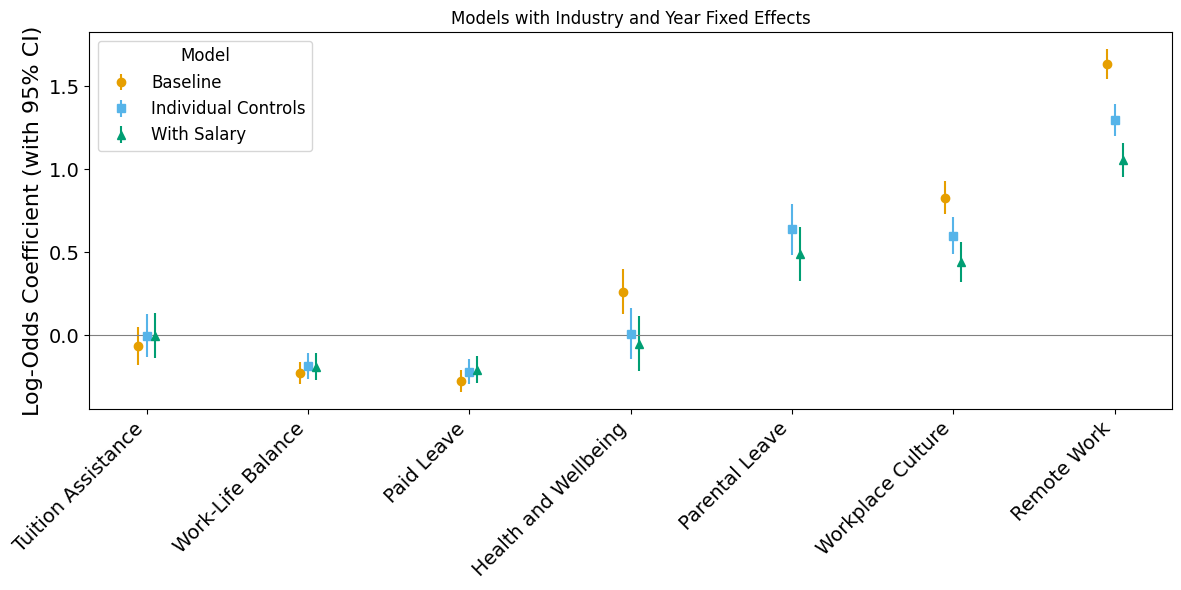

In [248]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
industry_df['Lower_CI'] = industry_df['Coefficient'] - 1.96 * industry_df['Error']
industry_df['Upper_CI'] = industry_df['Coefficient'] + 1.96 * industry_df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = industry_df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits4:
    benefit_data = industry_df[industry_df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits4[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits4[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
            # if not model_data['Converged'].values[0]:  # Assuming Converged is boolean
                # ax.plot(pos, model_data['Coefficient'].values[0], 'rx', markersize=12, label='Did Not Converge')
        
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits4))]
ax.set_xticks(benefit_ticks, labels = benefits4_labels)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits4_labels, rotation=45, fontsize = 14, ha='right')
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel(None)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
plt.title('Models with Industry and Year Fixed Effects')
plt.tight_layout()
plt.savefig('../figures/model_coefficients_plot_industry.png')
plt.show()
